# AI-Based Voltage Estimation Tutorial | <font color=red>Part 1</font>: Neural Network-Based LV Voltage Estimation


## 1. Introduction

### Learning objective

This tutorial builds a neural network that estimates LV customer voltages from active and reactive power measurements.

The tutorial follows the methodology below:

1. load, convert and verify the simulated data;
2. fix the neural-network components and define the reduced search space;
3. use blocked K-fold validation to select hyperparameters;
4. compare random seeds 0–9 with the selected configuration; and
5. train the final model and evaluate the held-out test period.

<font color='red'>**<u>Note</u>:**</font> Run the notebook from top to bottom without skipping code cells. Change user settings only in the settings block unless an exercise states otherwise.


## 2. Tutorial

### 2.1 Task and simulated LV circuit

The simulated feeder contains 31 customers. At each time step, the model maps the customers' P and Q measurements to their voltage values:

`[P1, Q1, ..., P31, Q31]  →  neural network  →  [V1, ..., V31]`

Part 1 keeps the upstream condition fixed. The aim is to learn this input-to-output mapping before Part 2 introduces upstream-voltage variation.


<img style="float: middle;" src="LVnetwork-topology.png" width="60%">

**<center>Figure 1. Simulated LV circuit used in Part 1</center>**


### 2.2 Set up the tutorial

#### 2.2.1 Import libraries

Run the following cell once to load the tools used throughout the tutorial.


In [1]:
from pathlib import Path
import itertools
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)


#### 2.2.2 Review the user-adjustable settings

All values intended for user changes are collected below.

| Setting | Role in the workflow |
|---|---|
| Hidden neurons | Controls model capacity. |
| Activation | Adds nonlinearity to the hidden layer. |
| Learning rate | Controls the size of each Adam update. |
| Weight decay | Adds L2 regularisation. |
| Batch size | Sets the number of samples in one update. |
| Epochs | Sets the number of passes through the training data. |
| K-folds | Sets the number of consecutive validation blocks. |
| Seeds | Compare the effect of initialisation and mini-batch order. |

The model inputs, outputs, loss function, scaler and optimiser remain fixed so the tutorial has one clear comparison path.

<font color='red'>**<u>Note</u>:**</font> Keep `RUN_SEARCH=False` and `RUN_SEED_SEARCH=False` for the standard tutorial run. Setting either switch to `True` starts many additional training runs and can take a long time on a CPU.


In [2]:
# ============================================================
# USER-ADJUSTABLE SETTINGS
# Change values in this cell before running the workflow below.
# ============================================================

# Reproducibility and time-aware validation
SEED = 42
KFOLDS = 3

# Training-data visualisation
DAY_TO_PLOT = 1
CUSTOMERS_TO_PLOT = [1, 16, 31]  # 1-based customer numbers

# Blocked K-fold hyperparameter search
RUN_SEARCH = False  # True reruns every configuration below.
SEARCH_SPACE = {
    "hidden_multiplier": [3, 5],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [72],
    "epochs": [1000, 2000],
}

# Random-seed comparison after hyperparameter selection
RUN_SEED_SEARCH = False  # True evaluates every seed with blocked K-fold validation.
SEEDS_TO_TRY = list(range(10))
REPORTED_SELECTED_SEED = 1  # Selected by the completed methodology run.


#### 2.2.3 Initialise the folder, seed and device

This cell fixes reproducibility, records the working folder and selects a GPU when one is available.


In [3]:
WORKING_DIRECTORY = Path.cwd()


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Working directory: {WORKING_DIRECTORY.resolve()}")
print(f"Computation device: {DEVICE}")


Working directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_1_LV_Vol_Estimation
Computation device: cpu


### 2.3 Load and understand the data

#### 2.3.1 Load the training and test files

The training period is used for model fitting and hyperparameter selection. The test period stays separate until Section 2.6.

<font color='red'>**<u>Note</u>:**</font> Keep the complete tutorial folder together. The notebook needs the dataset folder, topology image and included result CSV in their supplied locations.


In [4]:
DATASET_NAME = "synthentic_data_5_min_LV"

# Accept both a notebook-local data folder and the proposed repository layout.
data_candidates = [
    WORKING_DIRECTORY / DATASET_NAME,
    WORKING_DIRECTORY / "data" / DATASET_NAME,
    WORKING_DIRECTORY.parent / "data" / DATASET_NAME,
    WORKING_DIRECTORY / "Tutorial_1_LV_Vol_Estimation" / DATASET_NAME,
]
DATA_DIRECTORY = next(
    (path for path in data_candidates if path.is_dir()),
    data_candidates[0],
)

data_files = {
    "PQ_tr": DATA_DIRECTORY / "training" / "PQ.pkl",
    "V_tr": DATA_DIRECTORY / "training" / "V.pkl",
    "PQ_te": DATA_DIRECTORY / "test" / "PQ.pkl",
    "V_te": DATA_DIRECTORY / "test" / "V.pkl",
}

missing_files = [path for path in data_files.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Missing simulated-data files:\n"
        + "\n".join(f"  - {path}" for path in missing_files)
    )

PQ_tr_df = pd.read_pickle(data_files["PQ_tr"])
V_tr_df = pd.read_pickle(data_files["V_tr"])
PQ_te_df = pd.read_pickle(data_files["PQ_te"])
V_te_df = pd.read_pickle(data_files["V_te"])

print(f"Dataset directory: {DATA_DIRECTORY.resolve()}")
print("Training and test files loaded.")


Dataset directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV
Training and test files loaded.


#### 2.3.2 Check and prepare the arrays

Before modelling, confirm that P/Q inputs and voltage targets have matching rows, the expected columns and no invalid values. The code then separates the interleaved P and Q columns for plotting.


In [5]:
def to_float32(df):
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    return numeric_df.to_numpy(np.float32)


PQ_tr = to_float32(PQ_tr_df)
V_tr = to_float32(V_tr_df)
PQ_te = to_float32(PQ_te_df)
V_te = to_float32(V_te_df)

assert PQ_tr.shape[0] == V_tr.shape[0]
assert PQ_te.shape[0] == V_te.shape[0]
assert PQ_tr.shape[1] == PQ_te.shape[1] == 62
assert V_tr.shape[1] == V_te.shape[1] == 31
assert all(np.isfinite(array).all() for array in [PQ_tr, V_tr, PQ_te, V_te])

# Columns are ordered P1, Q1, P2, Q2, ...
P_tr, Q_tr = PQ_tr[:, 0::2], PQ_tr[:, 1::2]
P_te, Q_te = PQ_te[:, 0::2], PQ_te[:, 1::2]
C = V_tr.shape[1]

dataset_summary = pd.DataFrame(
    {
        "data": ["Training P/Q", "Training voltage", "Test P/Q", "Test voltage"],
        "rows": [len(PQ_tr), len(V_tr), len(PQ_te), len(V_te)],
        "columns": [PQ_tr.shape[1], V_tr.shape[1], PQ_te.shape[1], V_te.shape[1]],
        "role": ["Model input", "Training target", "Final-test input", "Final-test target"],
        "minimum": [PQ_tr.min(), V_tr.min(), PQ_te.min(), V_te.min()],
        "maximum": [PQ_tr.max(), V_tr.max(), PQ_te.max(), V_te.max()],
    }
)
display(dataset_summary.round(3))


,data,rows,columns,role,minimum,maximum
0,Training P/Q,6048,62,Model input,-5.152000,11.625000
1,Training voltage,6048,31,Training target,245.440994,250.608002
2,Test P/Q,2016,62,Final-test input,-4.212000,17.499001
3,Test voltage,2016,31,Final-test target,247.289993,250.287994


#### 2.3.3 Visualise one training day

Inspecting the training data first gives context for the mapping the network will learn. The test targets are not plotted here because they are reserved for the final evaluation.

Use `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT` in the settings block to change the view.


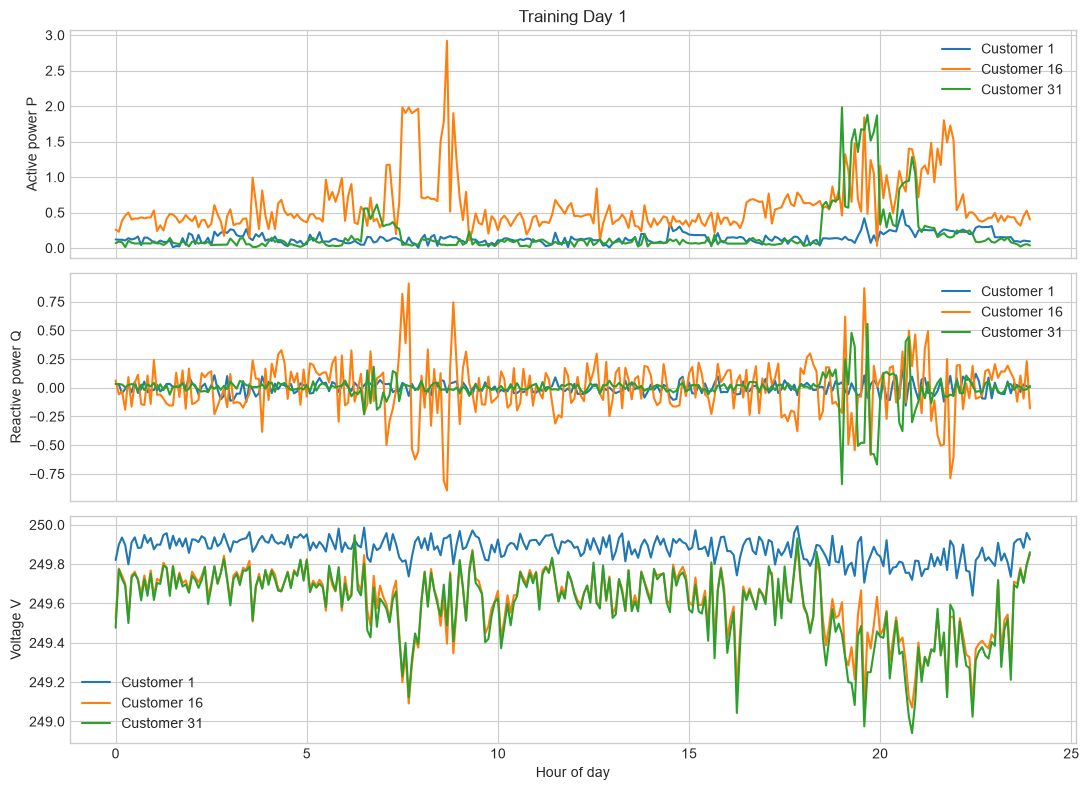

In [6]:
STEPS_PER_DAY = 24 * 60 // 5
available_days = len(PQ_tr) // STEPS_PER_DAY

if not 1 <= DAY_TO_PLOT <= available_days:
    raise ValueError(f"DAY_TO_PLOT must be between 1 and {available_days}.")
if not all(1 <= customer <= C for customer in CUSTOMERS_TO_PLOT):
    raise ValueError(f"Customer numbers must be between 1 and {C}.")

start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * 5 / 60
customer_indices = [customer - 1 for customer in CUSTOMERS_TO_PLOT]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for axis, matrix, label in zip(
    axes,
    [P_tr, Q_tr, V_tr],
    ["Active power P", "Reactive power Q", "Voltage V"],
):
    for customer, index in zip(CUSTOMERS_TO_PLOT, customer_indices):
        axis.plot(hours, matrix[start:end, index], label=f"Customer {customer}")
    axis.set_ylabel(label)
    axis.legend(loc="best")

axes[0].set_title(f"Training Day {DAY_TO_PLOT}")
axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()


### 2.4 Build the modelling workflow

#### 2.4.1 Define the neural network

The tutorial uses one hidden layer so the connection between the settings and the model remains visible. The input layer receives P/Q, and the output layer returns one voltage estimate per customer.

The following components stay fixed during model selection:

| Component | Fixed choice |
|---|---|
| Inputs / outputs | `2|C|` P/Q inputs and `|C|` voltage outputs |
| Hidden layers | One |
| Loss | MSE |
| Initialisation | Xavier uniform weights and zero bias |
| Scaling | MinMaxScaler |
| Output layer | Linear |
| Optimiser | Adam |


In [7]:
class NNi(nn.Module):
    """One-hidden-layer network for P/Q-to-voltage estimation."""

    def __init__(self, in_dim, out_dim, hidden_neurons, activation="tanh"):
        super().__init__()
        activations = {
            "tanh": nn.Tanh,
            "relu": nn.ReLU,
            "swish": nn.SiLU,
        }
        if activation not in activations:
            raise ValueError(f"Unsupported activation: {activation}")

        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_neurons),
            activations[activation](),
            nn.Linear(hidden_neurons, out_dim),
        )

        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, inputs):
        return self.network(inputs)


#### 2.4.2 Define blocked folds and fold-specific scaling

Nearby time samples are strongly related. Blocked validation keeps each validation period consecutive instead of randomly mixing individual rows.

Each fold fits its scalers on that fold's training blocks only. This prevents validation information from entering the model through normalisation.

<font color='red'>**<u>Note</u>:**</font> Fit each scaler on the fold's training rows only. Do not refit it on validation or test data.


In [8]:
def blocked_kfold_indices(n_instances, k=KFOLDS):
    """Create k adjacent validation blocks without shuffling time."""
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


def prepare_fold(PQ, V, training_indices, validation_indices):
    """Fit scalers on one fold's training blocks and transform both parts."""
    PQ_train, PQ_val = PQ[training_indices], PQ[validation_indices]
    V_train, V_val = V[training_indices], V[validation_indices]

    input_scaler = MinMaxScaler().fit(PQ_train)
    output_scaler = MinMaxScaler().fit(V_train)

    X_train = input_scaler.transform(PQ_train).astype(np.float32)
    Y_train = output_scaler.transform(V_train).astype(np.float32)
    X_val = input_scaler.transform(PQ_val).astype(np.float32)
    Y_val = output_scaler.transform(V_val).astype(np.float32)

    return X_train, Y_train, X_val, Y_val, input_scaler, output_scaler


#### 2.4.3 Define training and prediction

One training function is reused for K-fold comparison, seed comparison and final training. Predictions are converted back to volts before errors are calculated.


In [9]:
def train_model(model, X_train, Y_train, config):
    """Train one model with mini-batch Adam optimisation."""
    dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(Y_train),
    )
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = nn.MSELoss()

    for _ in range(config["epochs"]):
        model.train()
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()

    return model


def predict_unscaled(model, X_scaled, output_scaler):
    """Predict voltage and return it in volts rather than scaled units."""
    model.eval()
    with torch.inference_mode():
        scaled_prediction = model(
            torch.from_numpy(X_scaled).to(DEVICE)
        ).cpu().numpy()
    return output_scaler.inverse_transform(scaled_prediction)


#### 2.4.4 Define K-fold evaluation and grid search

For every configuration, the same three blocked folds are used. Mean validation RMSE ranks the configurations, while its standard deviation shows how much performance changes across validation periods.


In [10]:
def evaluate_config(config, PQ, V, k=KFOLDS, seed=SEED):
    """Evaluate one configuration on all blocked folds."""
    if "hidden_neurons" in config:
        hidden_neurons = int(config["hidden_neurons"])
    else:
        hidden_neurons = round(config["hidden_multiplier"] * V.shape[1])
    fold_rmse = []
    start_time = time.time()

    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        X_train, Y_train, X_val, _, _, output_scaler = prepare_fold(
            PQ, V, training_indices, validation_indices
        )

        set_seed(seed)
        model = NNi(
            in_dim=X_train.shape[1],
            out_dim=Y_train.shape[1],
            hidden_neurons=hidden_neurons,
            activation=config["activation"],
        )
        model = train_model(model, X_train, Y_train, config)

        V_val_estimated = predict_unscaled(model, X_val, output_scaler)
        V_val = V[validation_indices]
        fold_rmse.append(
            float(np.sqrt(np.mean((V_val - V_val_estimated) ** 2)))
        )

    return {
        "hidden_neurons": hidden_neurons,
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }


def run_grid_search(PQ, V, search_space=SEARCH_SPACE):
    """Evaluate and rank every configuration in the search space."""
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []

    for number, config in enumerate(configurations, start=1):
        scores = evaluate_config(config, PQ, V)
        rows.append({**config, **scores})
        print(
            f"Configuration {number}/{len(configurations)}: "
            f"RMSE={scores['RMSE_kfold']:.6f} V"
        )

    return (
        pd.DataFrame(rows)
        .sort_values("RMSE_kfold")
        .reset_index(drop=True)
    )


def run_seed_search(PQ, V, config, seeds=SEEDS_TO_TRY):
    """Compare random seeds using the selected configuration and blocked folds."""
    rows = []
    for seed in seeds:
        scores = evaluate_config(config, PQ, V, seed=seed)
        rows.append(
            {
                "seed": seed,
                "RMSE_kfold": scores["RMSE_kfold"],
                "RMSE_std": scores["RMSE_std"],
            }
        )
        print(
            f"Seed {seed}: mean validation RMSE="
            f"{scores['RMSE_kfold']:.6f} V"
        )

    return (
        pd.DataFrame(rows)
        .sort_values("RMSE_kfold")
        .reset_index(drop=True)
    )


### 2.5 Select and train the final model

#### 2.5.1 Select hyperparameters with blocked K-fold validation

A broad search is expensive and distracts from the teaching workflow. The tutorial keeps a smaller space that still demonstrates how several settings are compared.

| Hyperparameter | Broader method space | Tutorial space |
|---|---|---|
| Hidden neurons | `[0.5, 1, 2, ..., 10] × C` | `[3, 5] × C` |
| Activation | `tanh`, `ReLU`, `swish` | `tanh` |
| Learning rate | `1e-3`, `1e-4`, `1e-5` | `1e-3`, `1e-4` |
| Weight decay | `1e-3`, `1e-4`, `1e-5` | `1e-4`, `1e-5` |
| Batch size | 72, 144, 288 | 72 |
| Epochs | 1,000, 2,000, 5,000 | 1,000, 2,000 |

The included CSV stores the completed K-fold results so the tutorial can run quickly. Set `RUN_SEARCH=True` to reproduce every fit using the displayed search space.

<font color='red'>**<u>Note</u>:**</font> Select hyperparameters using blocked-validation results only. Do not use the held-out test period to rank configurations.


In [11]:
fold_summary = pd.DataFrame(
    [
        {
            "fold": fold_number,
            "training rows": len(training_indices),
            "validation rows": len(validation_indices),
            "validation range (1-based)": (
                f"{validation_indices[0] + 1}–{validation_indices[-1] + 1}"
            ),
        }
        for fold_number, (training_indices, validation_indices) in enumerate(
            blocked_kfold_indices(len(PQ_tr), KFOLDS), start=1
        )
    ]
)
display(fold_summary)

if RUN_SEARCH:
    search_results = run_grid_search(PQ_tr, V_tr)
    search_source = "newly calculated results"
else:
    result_candidates = [
        WORKING_DIRECTORY / "LV_search_results.csv",
        DATA_DIRECTORY.parent / "LV_search_results.csv",
        WORKING_DIRECTORY
        / "Tutorial_1_LV_Vol_Estimation"
        / "LV_search_results.csv",
    ]
    results_path = next(
        (path for path in result_candidates if path.is_file()),
        result_candidates[0],
    )
    if not results_path.is_file():
        raise FileNotFoundError("LV_search_results.csv was not found.")
    search_results = pd.read_csv(results_path)
    search_source = f"included results: {results_path.name}"

search_results = search_results.sort_values("RMSE_kfold").reset_index(drop=True)
columns_to_show = [
    "hidden_neurons",
    "activation",
    "lr",
    "weight_decay",
    "batch_size",
    "epochs",
    "RMSE_kfold",
    "RMSE_std",
]

print(f"Using {search_source}")
print("Top five configurations:")
display(search_results[columns_to_show].head(5).round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}

print("Selected configuration:")
for name, value in best_config.items():
    print(f"  {name}: {value}")
print(f"Mean blocked K-fold RMSE: {best_row['RMSE_kfold']:.6f} V")


,fold,training rows,validation rows,validation range (1-based)
0,1,4032,2016,1–2016
1,2,4032,2016,2017–4032
2,3,4032,2016,4033–6048


Using included results: LV_search_results.csv
Top five configurations:


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,RMSE_kfold,RMSE_std
0,155,tanh,0.0001,0.00001,72,2000,0.010986,0.000593
1,93,tanh,0.0001,0.00001,72,2000,0.011058,0.001003
2,155,tanh,0.0001,0.00001,72,1000,0.011156,0.001125
3,93,tanh,0.0010,0.00001,72,1000,0.011737,0.001098
4,93,tanh,0.0001,0.00001,72,1000,0.011823,0.001172


Selected configuration:
  hidden_neurons: 155
  activation: tanh
  lr: 0.0001
  weight_decay: 1e-05
  batch_size: 72
  epochs: 2000
Mean blocked K-fold RMSE: 0.010986 V


Read the selection table from top to bottom:

- lower `RMSE_kfold` indicates better average validation accuracy;
- lower `RMSE_std` indicates more consistent performance across blocks; and
- the first row supplies the final model settings.

The test period has not been used to rank configurations.


#### 2.5.2 Compare random seeds

Keep the selected hyperparameters fixed and train the same network with seeds 0–9. A seed changes the initial weights and mini-batch order, so the trained result can change even when every hyperparameter is identical.

Following the methodology, seeds are compared by mean blocked-validation RMSE. The included tutorial uses the reported selected seed by default; set `RUN_SEED_SEARCH=True` to reproduce all ten three-fold comparisons.

Random seed is handled after hyperparameter selection so the two decisions remain clear:

- K-fold grid search selects the network and training settings;
- the seed comparison selects a repeatable training run for those fixed settings.


In [12]:
# Hyperparameters stay fixed while only the random seed changes.
if RUN_SEED_SEARCH:
    seed_results = run_seed_search(
        PQ_tr,
        V_tr,
        best_config,
        seeds=SEEDS_TO_TRY,
    )
    selected_seed = int(seed_results.iloc[0]["seed"])
    display(seed_results.round(6))
else:
    selected_seed = REPORTED_SELECTED_SEED
    print(
        "Using the selected seed from the completed methodology run. "
        "Set RUN_SEED_SEARCH=True to reproduce the ten-seed comparison."
    )

print(f"Seeds considered: {SEEDS_TO_TRY}")
print(f"Selected seed: {selected_seed}")


Using the selected seed from the completed methodology run. Set RUN_SEED_SEARCH=True to reproduce the ten-seed comparison.
Seeds considered: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Selected seed: 1


#### 2.5.3 Train the final model

The hyperparameters and random seed are now fixed. Refit the scalers on the complete training period and train the final model. The test voltage targets remain unused.


In [13]:
# Hyperparameters and seed are fixed. Scalers can now use all training rows.
input_scaler_full = MinMaxScaler().fit(PQ_tr)
output_scaler_full = MinMaxScaler().fit(V_tr)

X_train_full = input_scaler_full.transform(PQ_tr).astype(np.float32)
Y_train_full = output_scaler_full.transform(V_tr).astype(np.float32)
X_test_full = input_scaler_full.transform(PQ_te).astype(np.float32)

set_seed(selected_seed)
FINAL_MODEL = NNi(
    in_dim=X_train_full.shape[1],
    out_dim=Y_train_full.shape[1],
    hidden_neurons=best_config["hidden_neurons"],
    activation=best_config["activation"],
)
FINAL_MODEL = train_model(
    FINAL_MODEL,
    X_train_full,
    Y_train_full,
    best_config,
)

print("Final model trained on the complete training period.")
print(f"Selected seed: {selected_seed}")
print("The test voltage targets have not been used.")


Final model trained on the complete training period.
Selected seed: 1
The test voltage targets have not been used.


### 2.6 Evaluate the held-out test period

#### 2.6.1 Check overall accuracy

<font color='red'>**<u>Note</u>:**</font> Use the test period only after the hyperparameters, random seed and final model have been fixed.

- RMSE summarises overall error and gives larger errors more weight.
- MAE reports the average absolute difference in volts.
- The parity plot compares every estimated voltage with its simulated target.
- The deviation histogram shows how the absolute errors are distributed.


,metric,value (V)
0,Overall RMSE,0.012346
1,Mean absolute error,0.007468


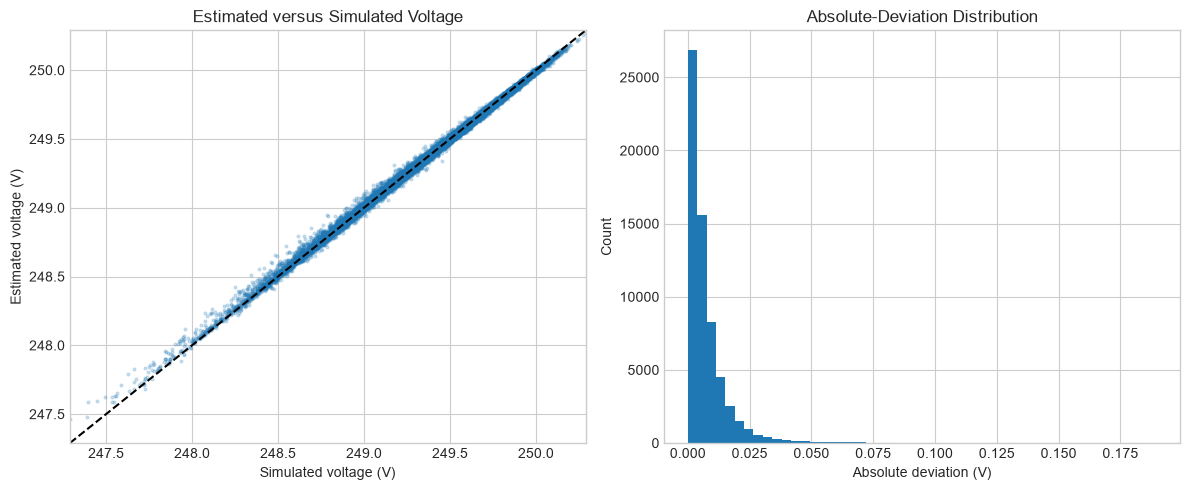

In [14]:
V_test_estimated = predict_unscaled(
    FINAL_MODEL, X_test_full, output_scaler_full
)
test_error = V_test_estimated - V_te

test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
test_mae = float(np.mean(np.abs(test_error)))
per_customer_rmse = np.sqrt(np.mean(test_error ** 2, axis=0))

test_metrics = pd.DataFrame(
    {
        "metric": ["Overall RMSE", "Mean absolute error"],
        "value (V)": [test_rmse, test_mae],
    }
)
display(test_metrics.round(6))

voltage_limits = [
    min(float(V_te.min()), float(V_test_estimated.min())),
    max(float(V_te.max()), float(V_test_estimated.max())),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(
    V_te.ravel(),
    V_test_estimated.ravel(),
    s=4,
    alpha=0.2,
)
axes[0].plot(voltage_limits, voltage_limits, "--", color="black")
axes[0].set_xlim(voltage_limits)
axes[0].set_ylim(voltage_limits)
axes[0].set_xlabel("Simulated voltage (V)")
axes[0].set_ylabel("Estimated voltage (V)")
axes[0].set_title("Estimated versus Simulated Voltage")

axes[1].hist(np.abs(test_error).ravel(), bins=50, color="tab:blue")
axes[1].set_xlabel("Absolute deviation (V)")
axes[1].set_ylabel("Count")
axes[1].set_title("Absolute-Deviation Distribution")

plt.tight_layout()
plt.show()


#### 2.6.2 Locate and inspect larger errors

An overall metric can hide differences between customers. Compare customer-level RMSE, then inspect the voltage trace and residual of the customer with the highest RMSE.

This connects one overall number to the time-series behaviour that produced it.


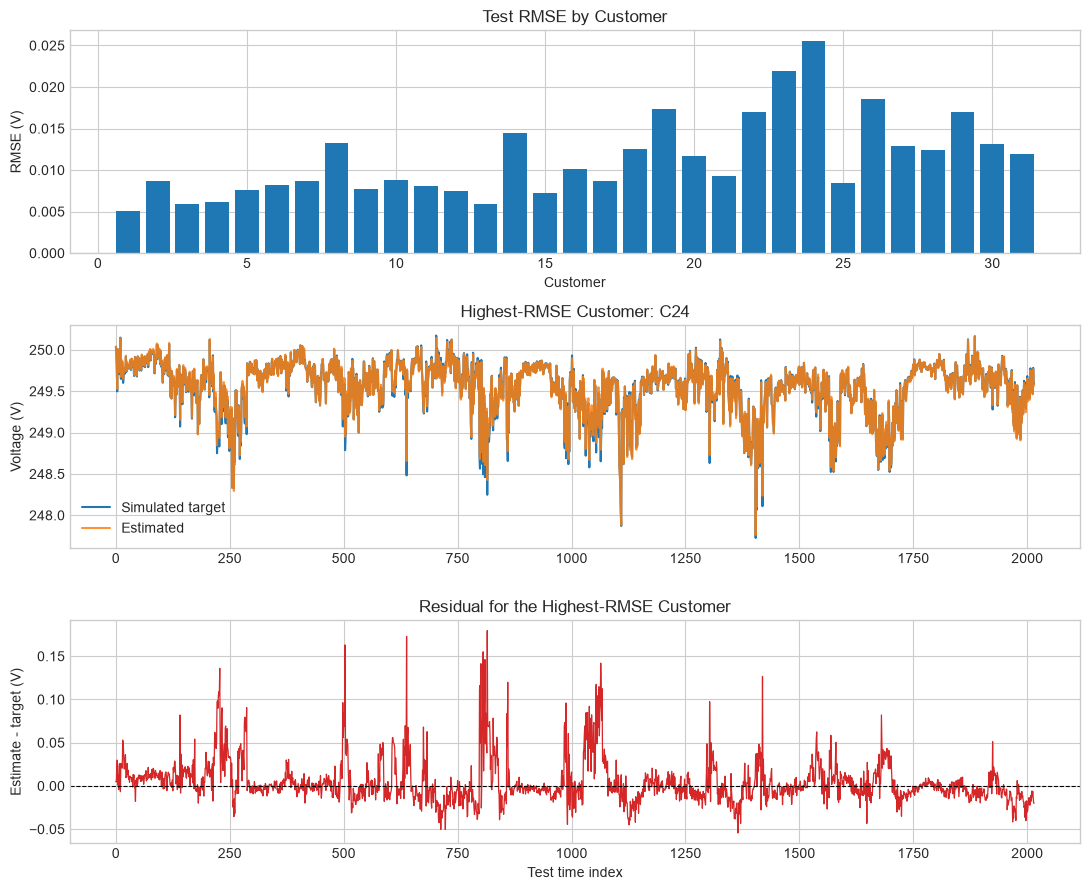

Highest-RMSE customer: C24
Customer RMSE: 0.025529 V


In [15]:
worst_customer = int(np.argmax(per_customer_rmse))
time_index = np.arange(len(V_te))

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

axes[0].bar(np.arange(1, C + 1), per_customer_rmse)
axes[0].set_xlabel("Customer")
axes[0].set_ylabel("RMSE (V)")
axes[0].set_title("Test RMSE by Customer")

axes[1].plot(
    time_index,
    V_te[:, worst_customer],
    label="Simulated target",
)
axes[1].plot(
    time_index,
    V_test_estimated[:, worst_customer],
    label="Estimated",
    alpha=0.85,
)
axes[1].set_ylabel("Voltage (V)")
axes[1].set_title(f"Highest-RMSE Customer: C{worst_customer + 1}")
axes[1].legend()

axes[2].plot(
    time_index,
    test_error[:, worst_customer],
    color="tab:red",
    linewidth=0.9,
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("Test time index")
axes[2].set_ylabel("Estimate - target (V)")
axes[2].set_title("Residual for the Highest-RMSE Customer")

plt.tight_layout()
plt.show()

print(f"Highest-RMSE customer: C{worst_customer + 1}")
print(f"Customer RMSE: {per_customer_rmse[worst_customer]:.6f} V")


**Result check**

The estimated points should remain close to the diagonal in the parity plot. The customer chart and residual trace then show where the remaining error is concentrated.

The complete modelling story is now visible: **training data → blocked validation → selected configuration → seed comparison → full training → one final test**.


## 3. Exercises

Use the existing functions and change only the stated settings.

<font color='red'>**<u>Note</u>:**</font> Keep the test period outside E.1 and E.2. Use it once in E.3 after the exercise configuration and seed have been selected.

### E.1 — Check blocked validation and scaling

- Report the three consecutive validation ranges.
- For each fold, check whether validation values extend outside `[0, 1]` after training-only scaling.
- Explain why the scaler must not be refitted on validation data.

### E.2 — Compare two activation functions

- Compare `tanh` and `relu` with 93 and 155 hidden neurons.
- Keep learning rate `1e-3`, weight decay `1e-5`, batch size 72 and epochs 300.
- Rank the four configurations by mean blocked K-fold RMSE without using the test period.

### E.3 — Compare seeds, then inspect the exercise model

- Use the best E.2 configuration and compare seeds 0, 1 and 2 with blocked validation.
- Select the seed with the lowest mean validation RMSE.
- Retrain that seed on the complete training period.
- Evaluate the test period once, report overall RMSE and identify the highest-RMSE customer.
- Use its residual plot to describe whether errors are persistent or concentrated in shorter periods.

Complete solutions are provided in `Tutorial_1_LV_Voltage_Estimation_Exercise_Solutions.ipynb`.
